# Phân bố kích thước lỗi trên PKU-Market-PCB

Notebook Tuần 3 này chỉ phân tích dataset `PKU-Market-PCB(Data enhanced version)` tại `data/raw/`. Notebook chỉ đọc ảnh và nhãn YOLO gốc, sau đó ghi các bảng thống kê và biểu đồ vào `results/`; không sửa dữ liệu thô.

Mỗi dòng nhãn YOLO hợp lệ được quy đổi thành một bounding box. Phân tích dùng từng liên kết ảnh-nhãn duy nhất, vì một số ảnh tăng cường nằm trong thư mục con của `images/` trong khi nhãn tương ứng nằm phẳng ở thư mục `labels/` cùng cấp.

## Quy ước đo tại `imgsz=640`

Kích thước `w_px`, `h_px` và `area_px` trong báo cáo **không** dùng pixel ảnh gốc. Mỗi ảnh có kích thước gốc `(W, H)` được scale theo kiểu letterbox giữ tỷ lệ vào canvas `640 x 640`, với hệ số `gain = min(640 / W, 640 / H)`. Phần padding không làm thay đổi kích thước box, nên `w_px = w_yolo * W * gain`, `h_px = h_yolo * H * gain` và `area_px = w_px * h_px`. Đây là không gian pixel mà mô hình nhìn thấy trước padding.

`relative_area` là `area_box_goc / area_anh_goc = w_yolo * h_yolo`. Đại lượng này là tỷ phần diện tích vật thể trên nội dung ảnh và không đổi khi scale giữ tỷ lệ; padding 640 không được đưa vào mẫu số.

Các bin COCO được cố định tại `imgsz=640`: **nhỏ** khi `area_px < 32^2 = 1024`; **trung bình** khi `1024 <= area_px <= 96^2 = 9216`; **lớn** khi `area_px > 9216`.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


IMAGE_SUFFIXES = {'.bmp', '.jpeg', '.jpg', '.png', '.tif', '.tiff', '.webp'}
IMGSZ = 640
SMALL_LIMIT = 32 ** 2
MEDIUM_LIMIT = 96 ** 2


def project_root() -> Path:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / 'data').is_dir() and (candidate / 'results').is_dir():
            return candidate
    raise RuntimeError('Không tìm thấy thư mục gốc của dự án.')


ROOT = project_root()
DATASET_DIR = ROOT / 'data/raw/PKU-Market-PCB(Data enhanced version)'
RESULTS_DIR = ROOT / 'results'

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f'Không tìm thấy dataset PKU: {DATASET_DIR}')

class_file = DATASET_DIR / 'Class.txt'
try:
    class_names = list(ast.literal_eval(class_file.read_text(encoding='utf-8').strip()))
except (SyntaxError, ValueError) as error:
    raise ValueError('Class.txt phải là danh sách tên lớp hợp lệ.') from error
if not class_names or not all(isinstance(name, str) and name for name in class_names):
    raise ValueError('Class.txt không chứa tên lớp hợp lệ.')


## Ghép ảnh và nhãn

Với ảnh dưới `.../images/...`, notebook thử nhãn phản chiếu trong `.../labels/...` trước. Nếu không tồn tại, notebook thử file có cùng tên ở `.../labels/` phẳng. Thứ tự này hỗ trợ đồng thời cấu trúc chuẩn và bất thường đã biết của ảnh tăng cường. Sau đó các cặp `(image_path, label_path)` được khử trùng lặp trước khi đọc nhãn.

In [2]:
def label_for_image(image_path: Path, dataset_dir: Path) -> Path | None:
    relative = image_path.relative_to(dataset_dir)
    if 'images' not in relative.parts:
        candidate = image_path.with_suffix('.txt')
        return candidate if candidate.is_file() else None

    index = relative.parts.index('images')
    labels_dir = dataset_dir.joinpath(*relative.parts[:index], 'labels')
    mirrored = labels_dir.joinpath(*relative.parts[index + 1:]).with_suffix('.txt')
    flattened = labels_dir / image_path.with_suffix('.txt').name
    return next((candidate for candidate in (mirrored, flattened) if candidate.is_file()), None)


image_paths = sorted(
    path for path in DATASET_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
)
pairs = {(image_path, label_for_image(image_path, DATASET_DIR)) for image_path in image_paths}
pairs = sorted((image_path, label_path) for image_path, label_path in pairs if label_path is not None)

if not pairs:
    raise RuntimeError('Không tìm thấy cặp ảnh-nhãn PKU nào.')

print(f'Tìm thấy {len(pairs):,} liên kết ảnh-nhãn duy nhất từ {len(image_paths):,} ảnh PKU.')


Tìm thấy 4,837 liên kết ảnh-nhãn duy nhất từ 4,837 ảnh PKU.


## Phân tích từng bounding box

Nhãn phải có đúng năm trường `class_id x_center y_center width height`. Tọa độ YOLO được kiểm tra nằm trong `[0, 1]`, đồng thời box không được vượt biên. Nếu dữ liệu không hợp lệ, notebook dừng với đường dẫn và số dòng để tránh đưa giá trị sai vào thống kê. Mỗi hàng xuất ra chứa đường dẫn tương đối của cả ảnh và nhãn, chỉ số dòng nhãn, lớp, kích thước ảnh gốc, hệ số scale 640, kích thước box sau scale, diện tích tương đối và bin kích thước.

In [3]:
def size_bin(area_px: float) -> str:
    if area_px < SMALL_LIMIT:
        return 'small'
    if area_px <= MEDIUM_LIMIT:
        return 'medium'
    return 'large'


def parse_boxes(image_path: Path, label_path: Path) -> list[dict[str, object]]:
    with Image.open(image_path) as image:
        original_width, original_height = image.size
    gain = min(IMGSZ / original_width, IMGSZ / original_height)
    rows = []

    for line_number, line in enumerate(label_path.read_text(encoding='utf-8').splitlines(), start=1):
        if not line.strip():
            continue
        fields = line.split()
        if len(fields) != 5:
            raise ValueError(f'{label_path}:{line_number} phải có đúng 5 trường YOLO.')
        try:
            class_id = int(fields[0])
            x_center, y_center, width, height = (float(value) for value in fields[1:])
        except ValueError as error:
            raise ValueError(f'{label_path}:{line_number} chứa giá trị YOLO không hợp lệ.') from error
        if class_id not in range(len(class_names)):
            raise ValueError(f'{label_path}:{line_number} có class_id ngoài phạm vi: {class_id}.')
        if not all(0 <= value <= 1 for value in (x_center, y_center, width, height)):
            raise ValueError(f'{label_path}:{line_number} có tọa độ ngoài [0, 1].')
        if width <= 0 or height <= 0:
            raise ValueError(f'{label_path}:{line_number} có box rỗng.')
        if x_center - width / 2 < 0 or x_center + width / 2 > 1 or y_center - height / 2 < 0 or y_center + height / 2 > 1:
            raise ValueError(f'{label_path}:{line_number} có box vượt biên ảnh.')

        width_px = width * original_width * gain
        height_px = height * original_height * gain
        area_px = width_px * height_px
        rows.append({
            'image_path': str(image_path.relative_to(DATASET_DIR)),
            'label_path': str(label_path.relative_to(DATASET_DIR)),
            'label_line': line_number,
            'class_id': class_id,
            'class_name': class_names[class_id],
            'original_width_px': original_width,
            'original_height_px': original_height,
            'scale_to_imgsz_640': gain,
            'w_px': width_px,
            'h_px': height_px,
            'area_px': area_px,
            'relative_area': width * height,
            'size_bin': size_bin(area_px),
        })
    return rows


box_rows = [row for image_path, label_path in pairs for row in parse_boxes(image_path, label_path)]
boxes = pd.DataFrame(box_rows)
if boxes.empty:
    raise RuntimeError('Các cặp ảnh-nhãn không chứa bounding box nào.')
boxes.head()


,image_path,label_path,label_line,class_id,class_name,original_width_px,original_height_px,scale_to_imgsz_640,w_px,h_px,area_px,relative_area,size_bin
0,test/images/01_missing_hole_01_1.jpg,test/labels/01_missing_hole_01_1.txt,1,0,Missing_hole,3034,1586,0.210943,14.976928,11.601846,173.760010,0.000812,small
1,test/images/01_missing_hole_01_1.jpg,test/labels/01_missing_hole_01_1.txt,2,0,Missing_hole,3034,1586,0.210943,13.922215,13.078444,182.080912,0.000850,small
2,test/images/01_missing_hole_01_1.jpg,test/labels/01_missing_hole_01_1.txt,3,0,Missing_hole,3034,1586,0.210943,14.976928,12.656559,189.556375,0.000885,small
3,test/images/01_missing_hole_02_1.jpg,test/labels/01_missing_hole_02_1.txt,1,0,Missing_hole,2587,1225,0.247391,16.327793,16.327793,266.596818,0.001375,small
4,test/images/01_missing_hole_02_1.jpg,test/labels/01_missing_hole_02_1.txt,2,0,Missing_hole,2587,1225,0.247391,9.895632,14.101276,139.541034,0.000719,small


## Xuất CSV và biểu đồ

`size_distribution_boxes.csv` là dữ liệu mức bounding box để kiểm tra hoặc tái sử dụng. `size_distribution_statistics.csv` tổng hợp số box, các bin cố định và các thống kê diện tích tại không gian `imgsz=640` theo lớp. Histogram dùng diện tích `area_px` sau scale với trục hoành log để vẫn quan sát được các box rất nhỏ; boxplot cũng dùng cùng đại lượng theo từng lớp.

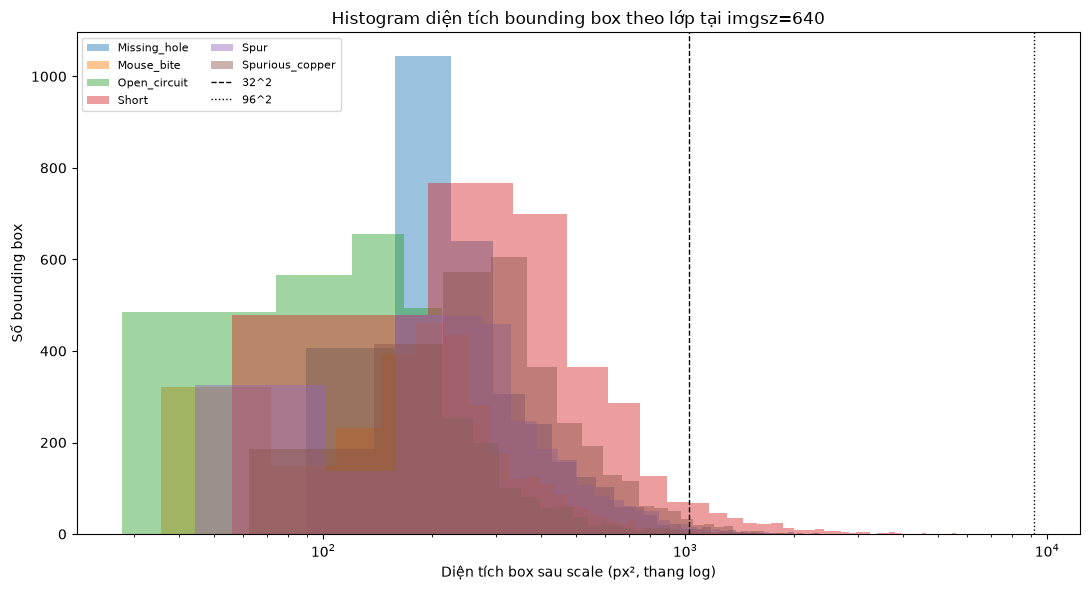

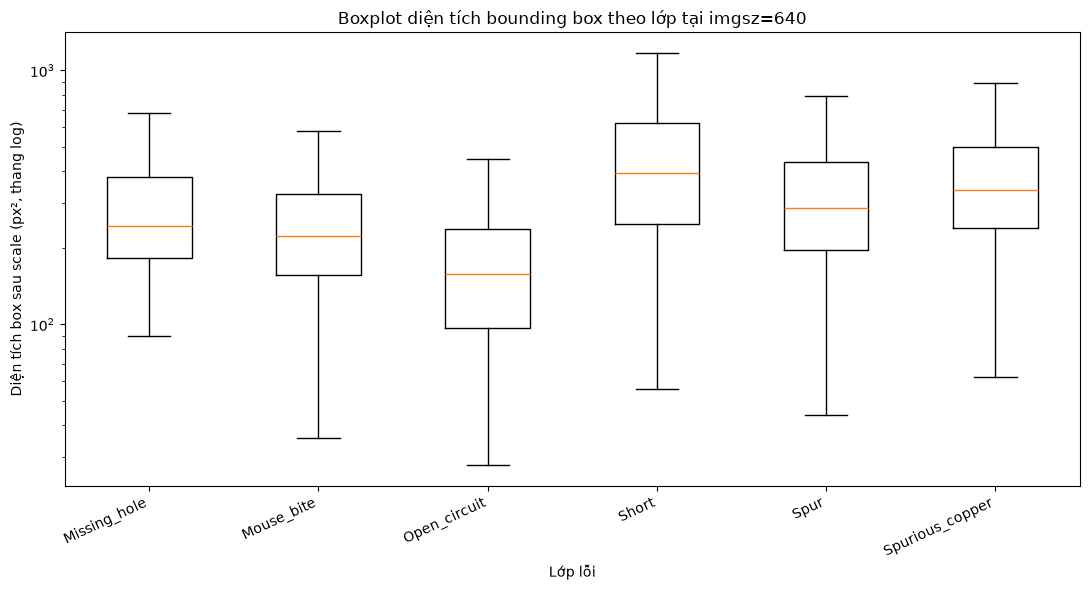

Đã ghi 19,003 bounding box từ 4,837 liên kết ảnh-nhãn duy nhất.
CSV từng box: /Users/Project/kltn-pcb/results/size_distribution_boxes.csv
CSV tổng hợp: /Users/Project/kltn-pcb/results/size_distribution_statistics.csv
Histogram: /Users/Project/kltn-pcb/results/size_distribution_histogram_by_class.png
Boxplot: /Users/Project/kltn-pcb/results/size_distribution_boxplot_by_class.png


,class_name,imgsz,box_count,area_px_min,area_px_median,area_px_mean,area_px_max,small,medium,large,small_definition,medium_definition,large_definition
0,Missing_hole,640,3306,89.616558,244.203832,324.888932,2808.242738,3233,73,0,area_px < 1024,1024 <= area_px <= 9216,area_px > 9216
1,Mouse_bite,640,3274,35.597441,222.143111,269.310409,1486.035763,3242,32,0,area_px < 1024,1024 <= area_px <= 9216,area_px > 9216
2,Open_circuit,640,3138,27.810501,157.938749,203.297574,1878.717119,3122,16,0,area_px < 1024,1024 <= area_px <= 9216,area_px > 9216
3,Short,640,3105,55.798989,393.673419,532.687595,5603.832196,2795,310,0,area_px < 1024,1024 <= area_px <= 9216,area_px > 9216
4,Spur,640,3038,44.051834,287.077252,351.520125,2338.470171,2963,75,0,area_px < 1024,1024 <= area_px <= 9216,area_px > 9216
5,Spurious_copper,640,3142,62.295522,336.507816,415.710251,3094.877388,3017,125,0,area_px < 1024,1024 <= area_px <= 9216,area_px > 9216


In [4]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
boxes_path = RESULTS_DIR / 'size_distribution_boxes.csv'
statistics_path = RESULTS_DIR / 'size_distribution_statistics.csv'
histogram_path = RESULTS_DIR / 'size_distribution_histogram_by_class.png'
boxplot_path = RESULTS_DIR / 'size_distribution_boxplot_by_class.png'

bin_counts = boxes.pivot_table(index='class_name', columns='size_bin', aggfunc='size', fill_value=0)
bin_counts = bin_counts.reindex(index=class_names, columns=['small', 'medium', 'large'], fill_value=0)
area_statistics = boxes.groupby('class_name')['area_px'].agg(
    box_count='count',
    area_px_min='min',
    area_px_median='median',
    area_px_mean='mean',
    area_px_max='max',
).reindex(class_names)
statistics = area_statistics.join(bin_counts).reset_index()
statistics.insert(1, 'imgsz', IMGSZ)
statistics['small_definition'] = 'area_px < 1024'
statistics['medium_definition'] = '1024 <= area_px <= 9216'
statistics['large_definition'] = 'area_px > 9216'

boxes.to_csv(boxes_path, index=False)
statistics.to_csv(statistics_path, index=False)

plt.figure(figsize=(11, 6))
for class_name in class_names:
    plt.hist(boxes.loc[boxes['class_name'] == class_name, 'area_px'], bins=40, alpha=0.45, label=class_name)
plt.xscale('log')
plt.axvline(SMALL_LIMIT, color='black', linestyle='--', linewidth=1, label='32^2')
plt.axvline(MEDIUM_LIMIT, color='black', linestyle=':', linewidth=1, label='96^2')
plt.title('Histogram diện tích bounding box theo lớp tại imgsz=640')
plt.xlabel('Diện tích box sau scale (px², thang log)')
plt.ylabel('Số bounding box')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(histogram_path, dpi=150)
plt.show()

plot_data = [boxes.loc[boxes['class_name'] == class_name, 'area_px'] for class_name in class_names]
plt.figure(figsize=(11, 6))
plt.boxplot(plot_data, tick_labels=class_names, showfliers=False)
plt.yscale('log')
plt.title('Boxplot diện tích bounding box theo lớp tại imgsz=640')
plt.xlabel('Lớp lỗi')
plt.ylabel('Diện tích box sau scale (px², thang log)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(boxplot_path, dpi=150)
plt.show()

print(f'Đã ghi {len(boxes):,} bounding box từ {len(pairs):,} liên kết ảnh-nhãn duy nhất.')
print(f'CSV từng box: {boxes_path}')
print(f'CSV tổng hợp: {statistics_path}')
print(f'Histogram: {histogram_path}')
print(f'Boxplot: {boxplot_path}')
statistics


## Kiểm tra tính đầy đủ của artifact

Cell cuối xác nhận mọi file đầu ra đã được tạo, số dòng dữ liệu bằng số bounding box đã phân tích, và tổng ba bin của mỗi lớp bằng tổng số box của lớp đó. Các kiểm tra này ngăn việc báo cáo thành công khi xuất file thiếu dữ liệu hoặc phân bin không đầy đủ.

In [5]:
for output_path in (boxes_path, statistics_path, histogram_path, boxplot_path):
    if not output_path.is_file() or output_path.stat().st_size == 0:
        raise AssertionError(f'Đầu ra không hợp lệ: {output_path}')

exported_boxes = pd.read_csv(boxes_path)
exported_statistics = pd.read_csv(statistics_path)
if len(exported_boxes) != len(boxes):
    raise AssertionError('Số dòng CSV từng box không khớp dữ liệu đã phân tích.')
if not (exported_statistics[['small', 'medium', 'large']].sum(axis=1) == exported_statistics['box_count']).all():
    raise AssertionError('Tổng số box theo bin không khớp số box theo lớp.')

print('Đã xác minh CSV, histogram, boxplot và tổng bin theo lớp.')


Đã xác minh CSV, histogram, boxplot và tổng bin theo lớp.
